In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
dataFrame = pd.read_excel("/content/drive/MyDrive/Tensorflow/merc.xlsx")

In [58]:
dataFrame.head()

,year,price,transmission,mileage,tax,mpg,engineSize
0,2005,5200,Automatic,63000,325,32.1,1.8
1,2017,34948,Automatic,27000,20,61.4,2.1
2,2016,49948,Automatic,6200,555,28.0,5.5
3,2016,61948,Automatic,16000,325,30.4,4.0
4,2016,73948,Automatic,4000,325,30.1,4.0


In [59]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [60]:
dataFrame.isnull() #null olup olmayan veilere bakarız

,year,price,transmission,mileage,tax,mpg,engineSize
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
13114,False,False,False,False,False,False,False
13115,False,False,False,False,False,False,False
13116,False,False,False,False,False,False,False
13117,False,False,False,False,False,False,False


In [61]:
dataFrame.isnull().sum() #hepsine tek tek bakamayacağımız için sum fonksiyonunu kullanalım

,0
year,0
price,0
transmission,0
mileage,0
tax,0
mpg,0
engineSize,0


bütün veriler tam. hiç null yok. boş veri yok

/tmp/ipython-input-2300367269.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(dataFrame["price"]) #distrubition plot (dağılım grafiği)


<Axes: xlabel='price', ylabel='Density'>

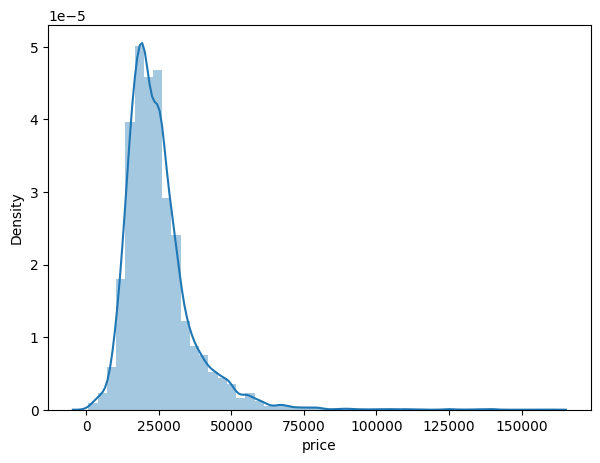

In [62]:
plt.figure(figsize=(7,5)) #7: Grafiğin genişliğini (width) temsil eder.
#5: Grafiğin yüksekliğini (height) temsil eder.

sbn.distplot(dataFrame["price"]) #distrubition plot (dağılım grafiği)

en pahalı arabalar yüzünden fiyat grafiği yukarda çıkabilir. daha iyi bir veri seti için birkaç pahalı arabayı çıkart.

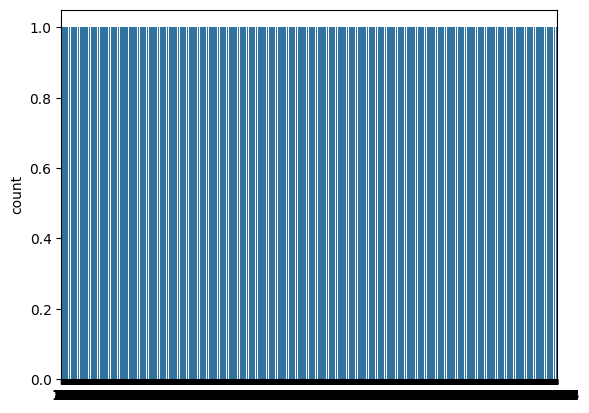

In [63]:
#dataFrame["year"].nunique() --> kaç tane farklı değer var
sbn.countplot(dataFrame["year"])
plt.show()

In [64]:
dataFrame.corr(numeric_only=True) #korelasyon
#sadece sayılar için yazdık. çünkü içinde string de olduğu için direk corr() ifadesinde hata verdi

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.520712,-0.738027,0.012480,-0.094626,-0.142147
price,0.520712,1.000000,-0.537214,0.268717,-0.438445,0.516126
mileage,-0.738027,-0.537214,1.000000,-0.160223,0.202850,0.063652
tax,0.012480,0.268717,-0.160223,1.000000,-0.513742,0.338341
mpg,-0.094626,-0.438445,0.202850,-0.513742,1.000000,-0.339862
engineSize,-0.142147,0.516126,0.063652,0.338341,-0.339862,1.000000


In [65]:
dataFrame.corr(numeric_only=True)["price"].sort_values() # sort_values() yazınca küçükten büyüğe dizer

,price
mileage,-0.537214
mpg,-0.438445
tax,0.268717
engineSize,0.516126
year,0.520712
price,1.000000


tax, engineSize , year  pozitif etkiliyor fiyatı. mileage ve mpg negatif etkiliyor

<Axes: xlabel='mileage', ylabel='price'>

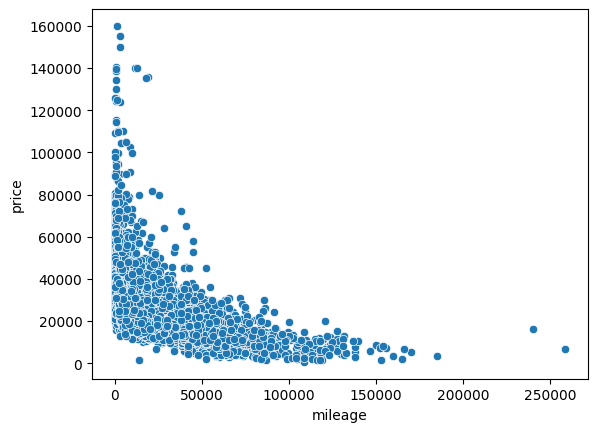

In [66]:
sbn.scatterplot(x="mileage", y="price", data=dataFrame)

In [67]:
dataFrame.sort_values("price",ascending = False).head(20) #ascending:yükselen
#scending = False en yüksek fiyatı en yukarı getirir
#head(20)  20 adet getirir

,year,price,transmission,mileage,tax,mpg,engineSize
6199,2020,159999,Semi-Auto,1350,145,21.4,4.0
10044,2020,154998,Automatic,3000,150,21.4,4.0
5,2011,149948,Automatic,3000,570,21.4,6.2
8737,2019,140319,Semi-Auto,785,150,22.1,4.0
6386,2018,139995,Semi-Auto,13046,145,21.4,4.0
8,2019,139948,Automatic,12000,145,21.4,4.0
9133,2019,139559,Semi-Auto,1000,145,22.1,4.0
8821,2020,138439,Semi-Auto,1000,145,22.1,4.0
5902,2018,135771,Semi-Auto,19000,145,21.4,4.0
7864,2018,135124,Semi-Auto,18234,150,21.4,4.0


In [68]:
dataFrame.sort_values("price",ascending = True).head(20) # en düşük fiyattan başlar

,year,price,transmission,mileage,tax,mpg,engineSize
11816,2003,650,Manual,109090,235,40.0,1.4
12008,2010,1350,Manual,116126,145,54.3,2.0
11765,2000,1490,Automatic,87000,265,27.2,3.2
11549,2002,1495,Automatic,13800,305,39.8,2.7
12594,2004,1495,Manual,119000,300,34.5,1.8
11174,2001,1695,Automatic,108800,325,31.7,3.2
12710,2006,1695,Automatic,153000,300,33.6,1.8
12766,2004,1780,Automatic,118000,265,41.5,2.2
12009,2007,1800,Automatic,84000,200,42.8,1.5
11764,1998,1990,Automatic,99300,265,32.1,2.3


In [69]:
len(dataFrame)

13119

bir veri setinin %99unu kullansak o verinin yansıttığı tabloyu bozmadan işlemlerimize devam edebiliriz. o zaman %1i kaç bulalım ve o kadar sayıda en yüksek araba fiyatını çıkartalım

In [70]:
len(dataFrame) * 0.01

131.19

In [71]:
yuzdeDoksanDokuzDf = dataFrame.sort_values("price",ascending = False).iloc[131:]
#iloc: indekse göre location. [131:] 131 sonrasındaki indexleri alır

In [72]:
yuzdeDoksanDokuzDf.describe()

,year,price,mileage,tax,mpg,engineSize
count,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000
mean,2017.281876,24074.926933,22132.741146,129.689714,55.437142,2.050901
std,2.228515,9866.224575,21196.776401,65.183076,15.025999,0.532596
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17357.500000,6322.000000,125.000000,45.600000,1.675000
50%,2018.000000,22299.000000,15369.500000,145.000000,56.500000,2.000000
75%,2019.000000,28706.000000,31982.250000,145.000000,64.200000,2.100000
max,2020.000000,65990.000000,259000.000000,580.000000,217.300000,6.200000


/tmp/ipython-input-1442147304.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(yuzdeDoksanDokuzDf["price"])


<Axes: xlabel='price', ylabel='Density'>

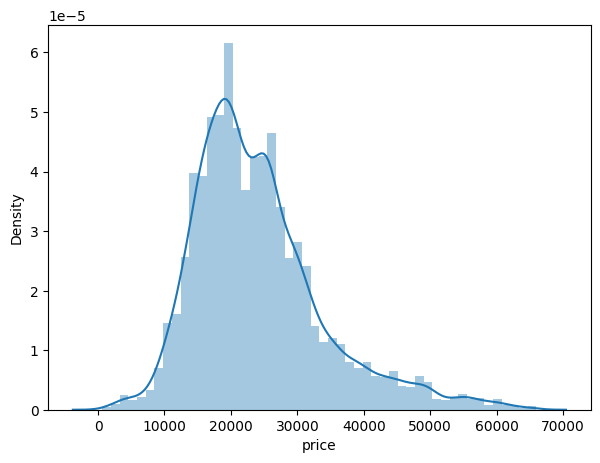

In [73]:
plt.figure(figsize=(7,5))
sbn.distplot(yuzdeDoksanDokuzDf["price"])

In [74]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [75]:
dataFrame.groupby("year").mean(numeric_only=True)["price"]
#yıllara göre grupla. mean(): ortalmasını al. price:fiyata göre

,price
year,
1970,24999.000000
1997,9995.000000
1998,8605.000000
1999,5995.000000
2000,5743.333333
2001,4957.900000
2002,5820.444444
2003,4878.000000
2004,4727.615385


In [76]:
yuzdeDoksanDokuzDf.groupby("year").mean(numeric_only=True)["price"]

,price
year,
1970,24999.000000
1997,9995.000000
1998,8605.000000
1999,5995.000000
2000,5743.333333
2001,4957.900000
2002,5820.444444
2003,4878.000000
2004,4727.615385


1970 yılında 25bin pounda satılması çok büyük bir sayı. veriden çıkartmak mantıklı olur

In [77]:
dataFrame[dataFrame.year != 1970].groupby("year").mean(numeric_only=True)["price"]
#normalde dataFrame[dataFrame[year] != 1970] şeklinde kullanırdık ama burada . kullanıyoruz.

,price
year,
1997,9995.000000
1998,8605.000000
1999,5995.000000
2000,5743.333333
2001,4957.900000
2002,5820.444444
2003,4878.000000
2004,4727.615385
2005,4426.111111


In [78]:
dataFrame = yuzdeDoksanDokuzDf

In [79]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000
mean,2017.281876,24074.926933,22132.741146,129.689714,55.437142,2.050901
std,2.228515,9866.224575,21196.776401,65.183076,15.025999,0.532596
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17357.500000,6322.000000,125.000000,45.600000,1.675000
50%,2018.000000,22299.000000,15369.500000,145.000000,56.500000,2.000000
75%,2019.000000,28706.000000,31982.250000,145.000000,64.200000,2.100000
max,2020.000000,65990.000000,259000.000000,580.000000,217.300000,6.200000


In [80]:
dataFrame = dataFrame[dataFrame.year != 1970]

In [81]:
dataFrame.groupby("year").mean(numeric_only=True)["price"]

,price
year,
1997,9995.000000
1998,8605.000000
1999,5995.000000
2000,5743.333333
2001,4957.900000
2002,5820.444444
2003,4878.000000
2004,4727.615385
2005,4426.111111


35bin 34e düştüğü 31bin 30a düştüğü ve 1970in hiç gözükmediği dataFrameimi en sonunda elde ettik.
verimizi çok güzel bir hale getirdik

In [82]:
dataFrame.head()

,year,price,transmission,mileage,tax,mpg,engineSize
6177,2019,65990,Semi-Auto,5076,150,30.4,3.0
5779,2020,65990,Semi-Auto,999,145,28.0,4.0
3191,2020,65980,Semi-Auto,3999,145,28.0,4.0
4727,2019,65000,Semi-Auto,3398,145,27.2,4.0
8814,2019,64999,Semi-Auto,119,145,40.9,3.0


transmission	kısmı numeric olmadığı için yok edelim bu şekilde işleme devam edemeyiz. regresyona sokamayız

In [83]:
dataFrame = dataFrame.drop("transmission", axis=1)
#kolonu axis 1den düşür yani tamamen yok et

In [84]:
y = dataFrame["price"].values
x = dataFrame.drop("price", axis=1).values

In [85]:
y

array([65990, 65990, 65980, ...,  1490,  1350,   650])

In [86]:
x

array([[2.01900e+03, 5.07600e+03, 1.50000e+02, 3.04000e+01, 3.00000e+00],
       [2.02000e+03, 9.99000e+02, 1.45000e+02, 2.80000e+01, 4.00000e+00],
       [2.02000e+03, 3.99900e+03, 1.45000e+02, 2.80000e+01, 4.00000e+00],
       ...,
       [2.00000e+03, 8.70000e+04, 2.65000e+02, 2.72000e+01, 3.20000e+00],
       [2.01000e+03, 1.16126e+05, 1.45000e+02, 5.43000e+01, 2.00000e+00],
       [2.00300e+03, 1.09090e+05, 2.35000e+02, 4.00000e+01, 1.40000e+00]])

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=10)

In [89]:
len(x_train)

9090

In [90]:
len(x_test)

3897

In [91]:
from sklearn.preprocessing import MinMaxScaler

In [92]:
scaler = MinMaxScaler()

In [93]:
x_train = scaler.fit_transform(x_train)

In [94]:
x_test = scaler.fit_transform(x_test)

In [95]:
from keras.models import Sequential
from keras.layers import Dense

In [96]:
x_train.shape

(9090, 5)

5 tane özellik varmış onun anlarız. 5 layers

#modeli oluşturalım

In [97]:
model = Sequential()

model.add(Dense(12,activation="relu"))
model.add(Dense(12,activation="relu"))
model.add(Dense(12,activation="relu"))
model.add(Dense(12,activation="relu"))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

#modeli eğitelim

In [99]:
model.fit(x=x_train,y=y_train,validation_data=(x_test,y_test),batch_size=250,epochs=300)
#validation_data bisiklet fiyatları işlemlerindei manuel işlemi otomatik yapıcak.
#batch_size: batchler halinde verileri vericez. parti parti. epochs kadar etkisi olmaz ama çok düşürürsen yapması uzun sürer.

Epoch 1/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19375180.0000 - val_loss: 22315212.0000
Epoch 2/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20124800.0000 - val_loss: 22252760.0000
Epoch 3/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19469242.0000 - val_loss: 22191370.0000
Epoch 4/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18968280.0000 - val_loss: 22216098.0000
Epoch 5/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19317466.0000 - val_loss: 22130970.0000
Epoch 6/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19101866.0000 - val_loss: 22103318.0000
Epoch 7/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19235462.0000 - val_loss: 22196688.0000
Epoch 8/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19432002.0000 - val_loss: 22402722.0000
Epoch 9/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 18898504.0000 - val_loss: 22229586.0000
Epoch 10/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19338992.0000 - val_loss: 22020928.0000
Epoch 11/

val_loss: validation_data yazdık validation loss da çıkar ekrana

In [101]:
kayipVerisi = pd.DataFrame(model.history.history)

In [102]:
kayipVerisi.head()

,loss,val_loss
0,19247714.0,22315212.0
1,19244530.0,22252760.0
2,19230234.0,22191370.0
3,19241864.0,22216098.0
4,19224268.0,22130970.0


<Axes: >

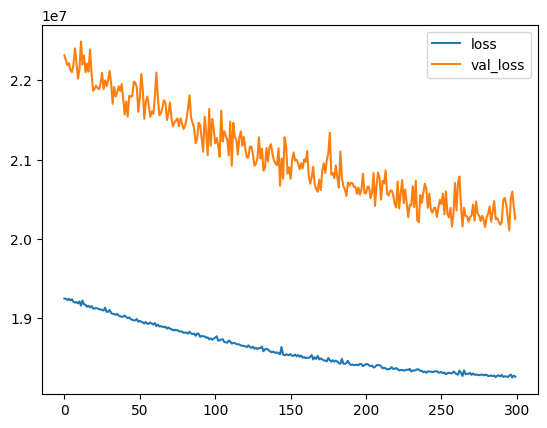

In [104]:
kayipVerisi.plot()

In [105]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [106]:
tahminDizisi = model.predict(x_test)

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [107]:
tahminDizisi

array([[26220.201],
       [21540.63 ],
       [26299.074],
       ...,
       [21730.627],
       [19239.043],
       [25868.367]], dtype=float32)

In [108]:
mean_absolute_error(y_test,tahminDizisi)

3230.69775390625

In [110]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,12987.000000,12987.000000,12987.000000,12987.000000,12987.000000,12987.000000
mean,2017.285516,24074.855779,22133.367367,129.676215,55.438392,2.051059
std,2.189633,9866.601115,21197.472376,65.167429,15.025902,0.532313
min,1997.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17355.000000,6320.000000,125.000000,45.600000,1.700000
50%,2018.000000,22299.000000,15371.000000,145.000000,56.500000,2.000000
75%,2019.000000,28706.000000,31986.500000,145.000000,64.200000,2.100000
max,2020.000000,65990.000000,259000.000000,580.000000,217.300000,6.200000


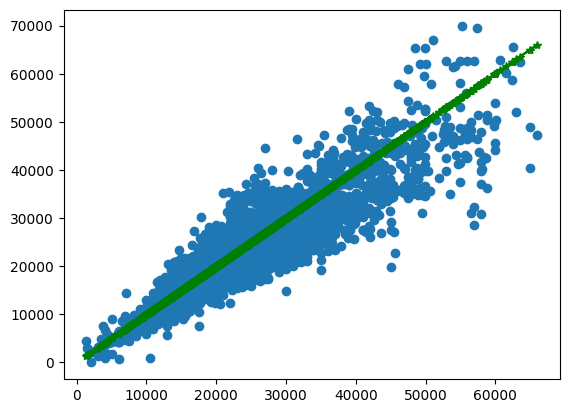

In [114]:
plt.scatter(y_test,tahminDizisi)
plt.plot(y_test,y_test,"g-*") #g green yapar. -* kalınlaştırır

In [115]:
dataFrame.iloc[2]

,3191
year,2020.0
price,65980.0
mileage,3999.0
tax,145.0
mpg,28.0
engineSize,4.0


In [118]:
yeniArabaSeries = dataFrame.drop("price",axis=1).iloc[2]

In [119]:
yeniArabaSeries

,3191
year,2020.0
mileage,3999.0
tax,145.0
mpg,28.0
engineSize,4.0


In [120]:
yeniArabaSeries = scaler.transform(yeniArabaSeries.values.reshape(-1,5))

In [121]:
model.predict(yeniArabaSeries)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


array([[64087.113]], dtype=float32)